In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from  sklearn.model_selection import train_test_split


In [4]:
titanic = sns.load_dataset("titanic")

In [5]:
# titanic.head()
# titanic.describe
# titanic.info()
titanic.isnull().sum()




survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [34]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [35]:
#  fill the missing values 
from sklearn.impute import SimpleImputer
imp_median =  SimpleImputer(strategy="median")
titanic[["age"]] =imp_median.fit_transform(titanic[["age"]])
imp_freq =  SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] =imp_freq.fit_transform(titanic[["embarked"]])

In [36]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [37]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [38]:
titanic.shape

(891, 15)

In [39]:
#  label encoding 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] =le.fit_transform(titanic["embarked"])

In [40]:
X= titanic[features]
y = titanic["survived"]

In [41]:
X.head()


,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [42]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [43]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.2,random_state=42)

In [45]:


X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [46]:
#  Decision tree  model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("accuracy_score:",accuracy_score(y_test,y_pred))

accuracy_score: 0.7653631284916201


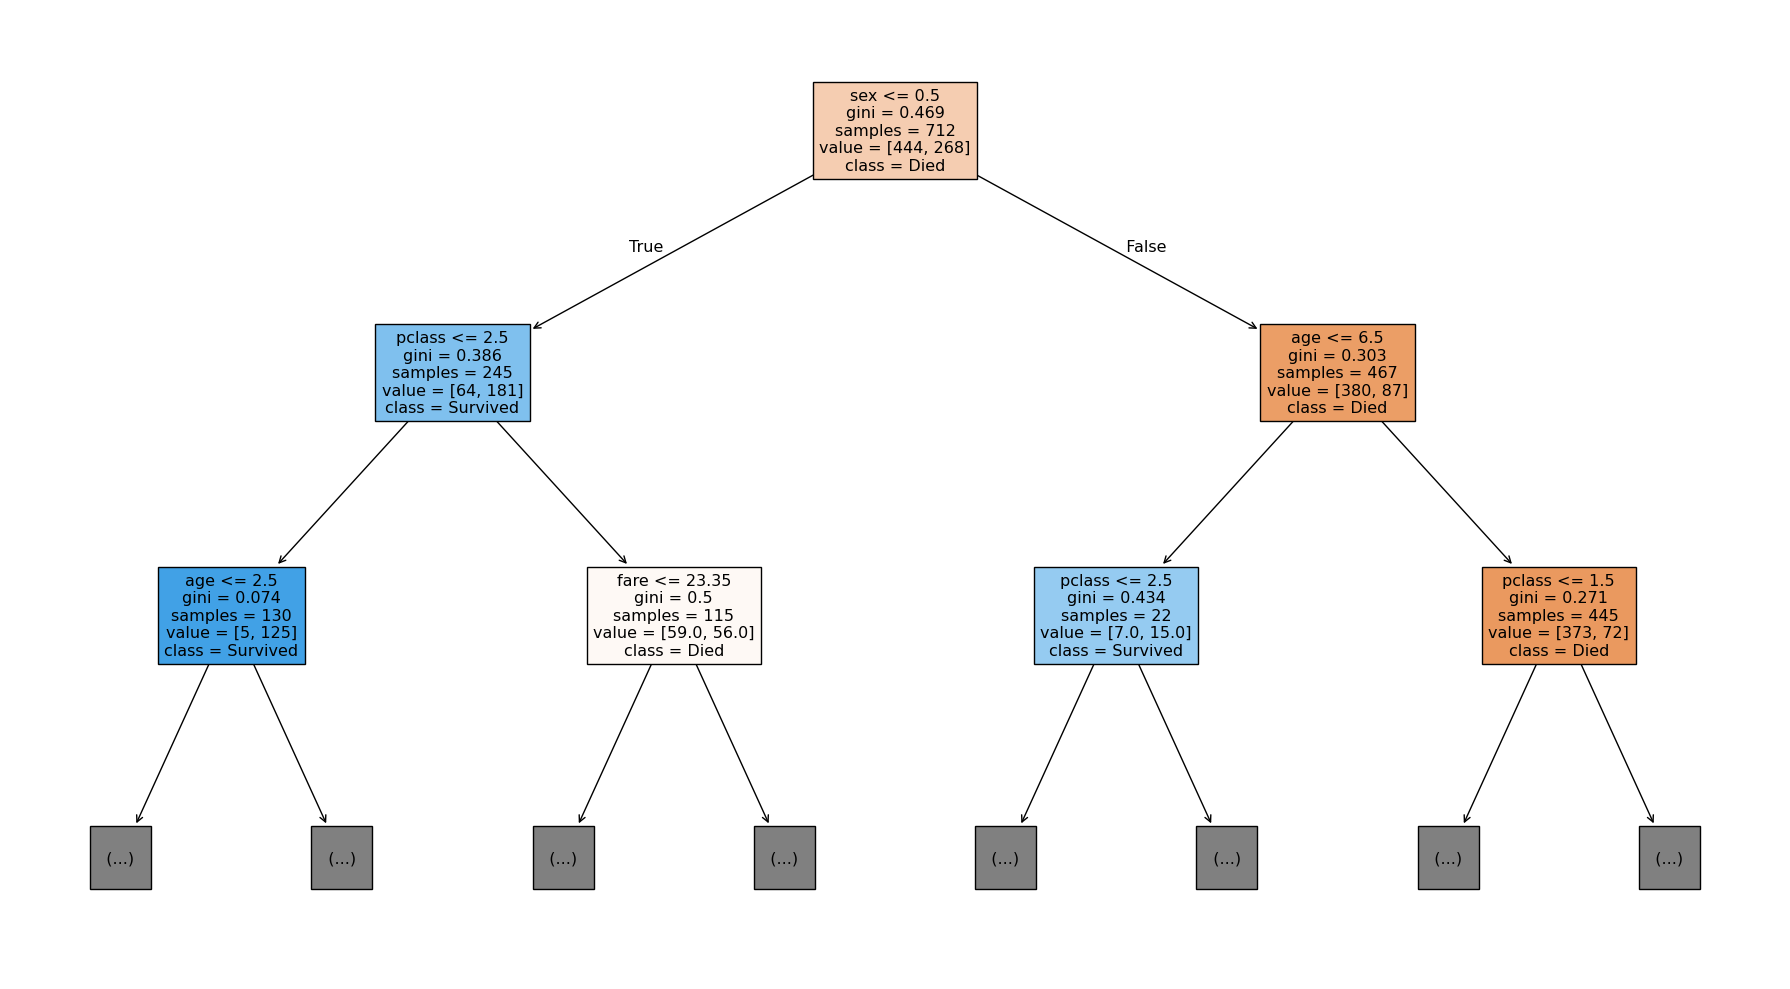

In [48]:

from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    max_depth = 2
)
plt.tight_layout()
plt.show()

for depth = 2, accuracy= 0.7653631284916201
for depth = 3, accuracy= 0.7988826815642458
for depth = 4, accuracy= 0.7988826815642458


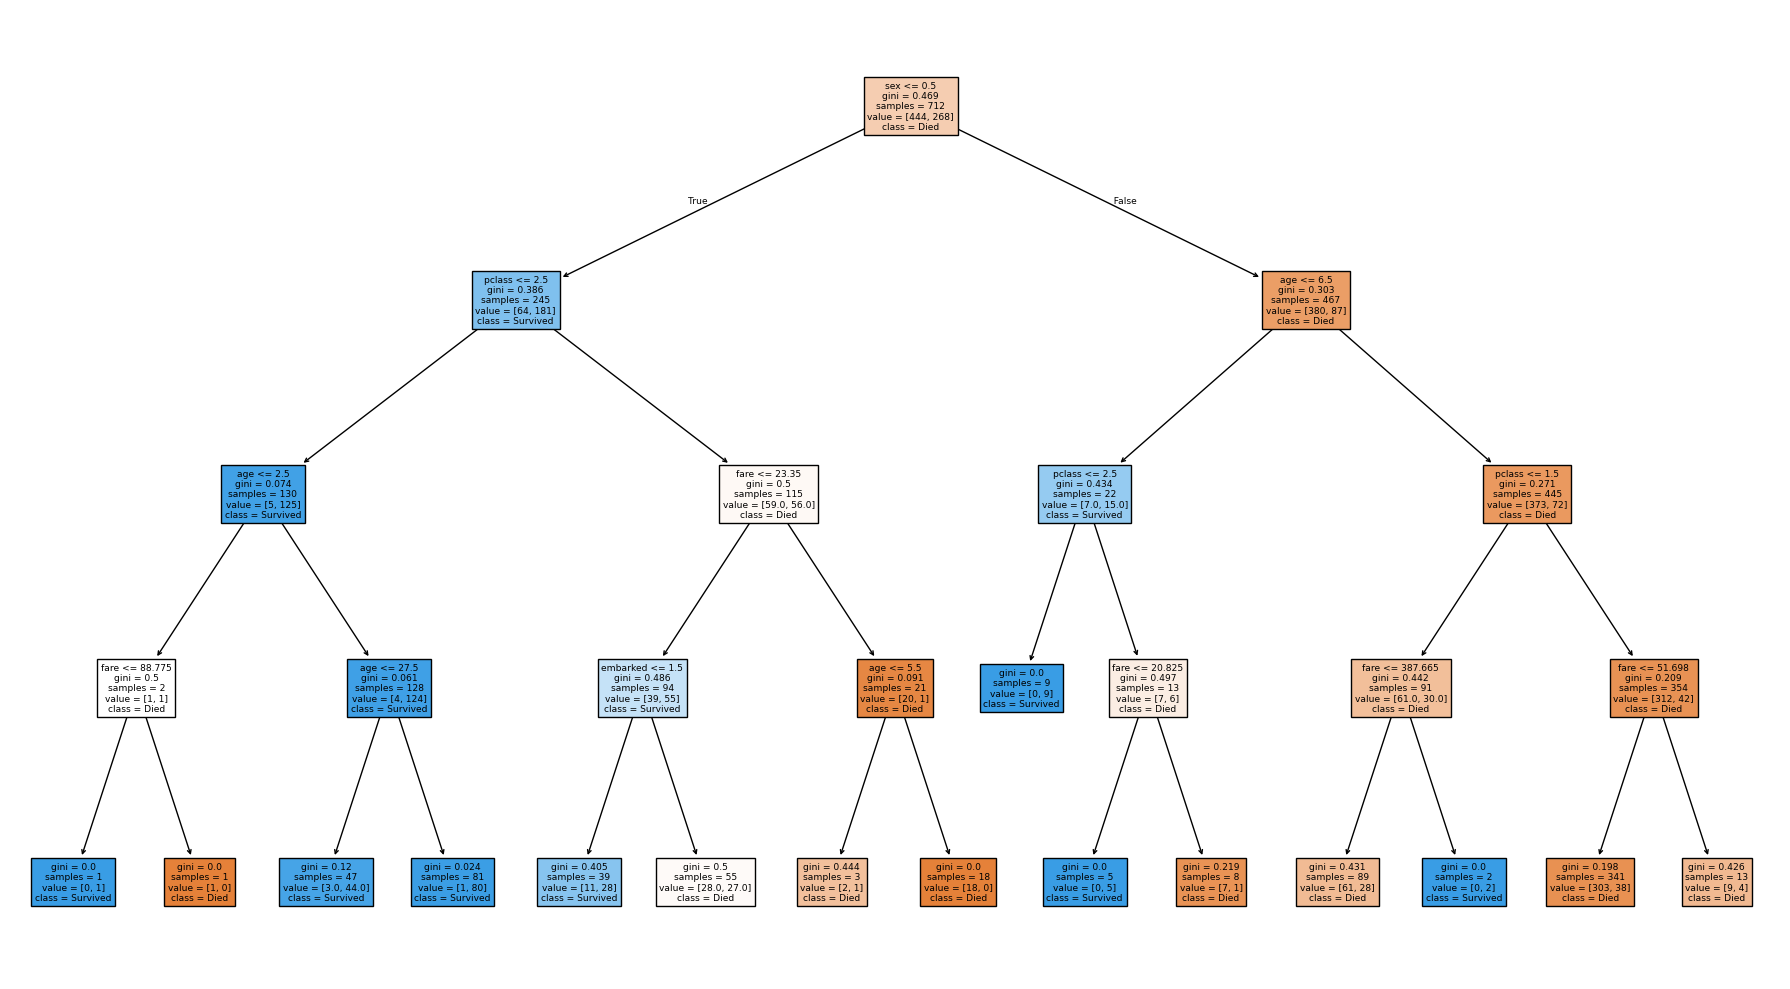

for depth = 5, accuracy= 0.7988826815642458
for depth = 6, accuracy= 0.7988826815642458
for depth = 7, accuracy= 0.8044692737430168
for depth = 8, accuracy= 0.7932960893854749
for depth = 9, accuracy= 0.7988826815642458
for depth = 10, accuracy= 0.7988826815642458


In [49]:
max_depth = [2,3,4,5,6,7,8,9,10]
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth= depth)
    model.fit(X_train,y_train)

    acc= model.score(X_test,y_test)
    print(f"for depth = {depth}, accuracy= {acc}")


    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(
         model,
         feature_names = X.columns,
         class_names = ["Died","Survived"],
         filled = True,
        
)
        plt.tight_layout()
        plt.show()
        
        
    


In [50]:

#  descision tree wiht full training
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [51]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [52]:
#  train all models for alphas
trees= []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    acc= model.score(X_test,y_test)
    trees.append((model,alpha))

In [53]:
best_acc = 0
best_alpha = 0


for model,alpha in trees:
    curr_acc= model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc= curr_acc
        best_alpha = alpha
        

In [54]:
best_acc

0.8379888268156425

In [55]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth=4)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


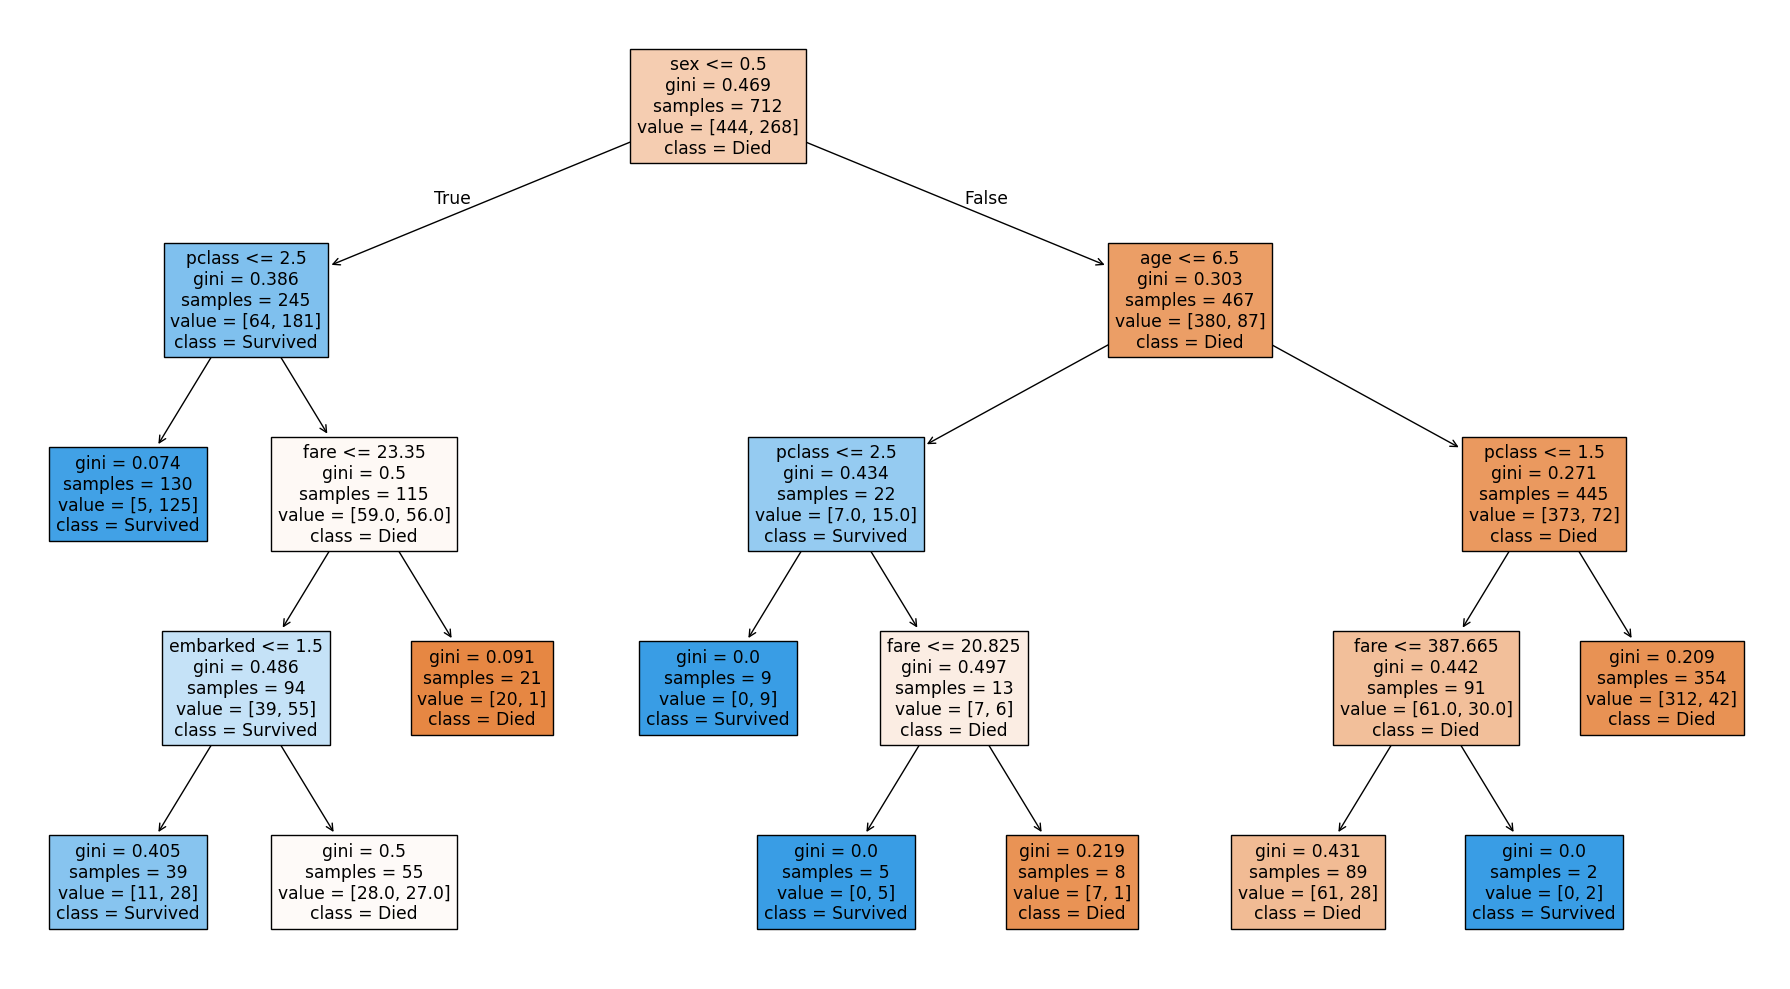

In [56]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    
)
plt.tight_layout()
plt.show()

In [57]:
print(best_model.score(X_train,y_train))

0.8384831460674157


In [71]:
#  RANDOM FOREST 
#  random forest is more stable to make a model more efficient
from sklearn.ensemble import RandomForestClassifier

rf  = RandomForestClassifier(
    n_estimators = 541,
    oob_score = True,
    max_depth = 4
)
rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)


print("oob_score",rf.oob_score_ * 100,"%")
print("testing_accuracy",accuracy_score(y_test,y_pred) * 100 , "%")

oob_score 82.4438202247191 %
testing_accuracy 81.56424581005587 %


In [67]:
titanic.shape

(891, 15)

In [77]:
#  bagging classifier and regressor'
from sklearn.ensemble import BaggingClassifier
base_model  = DecisionTreeClassifier()
bagging = BaggingClassifier(
    base_model,
    n_estimators= 201
)

bagging.fit(X_train,y_train)
y_pred  = bagging.predict(X_test)
print("accuracy_score:", accuracy_score(y_test,y_pred))

accuracy_score: 0.7932960893854749


In [76]:
from sklearn.linear_model import LogisticRegression
base_model  = LogisticRegression(max_iter= 1000)
bagging = BaggingClassifier(
    base_model,
    n_estimators= 201
)

bagging.fit(X_train,y_train)
y_pred  = bagging.predict(X_test)
print("accuracy_score:", accuracy_score(y_test,y_pred))

accuracy_score: 0.7988826815642458
